TASK 5: STRATEGY BACKTESTING

Loading data...
Loading fresh data...
✅ Data loaded: (2892, 3)
Close prices shape: (2892, 3)
Returns shape: (2891, 3)

5.1 LOAD PORTFOLIO WEIGHTS
⚠️ Weights not found. Using default weights...
Using default weights: TSLA=50%, BND=20%, SPY=30%

Strategy Weights:
TSLA: 50.00%
BND:  20.00%
SPY:  30.00%

5.2 DEFINE BACKTESTING PERIOD
Backtesting Period: 2025-01-01 to 2026-06-30
Trading Days: 373
Initial Investment: $100,000

5.3 BENCHMARK PORTFOLIO
Benchmark: 60% SPY / 40% BND
Benchmark Final Value: $120561.51
Benchmark Total Return: 20.56%

5.4 STRATEGY PORTFOLIO
Strategy Final Value: $117442.89
Strategy Total Return: 17.44%

5.5 MONTHLY REBALANCING
Rebalanced Final Value: $117442.89
Rebalanced Total Return: 17.44%

5.6 PERFORMANCE METRICS

PERFORMANCE METRICS COMPARISON:
               Metric  Strategy (Hold)  Strategy (Rebalanced)  Benchmark (60/40)
     Total Return (%)            17.44                  17.44              20.56
Annualized Return (%)       

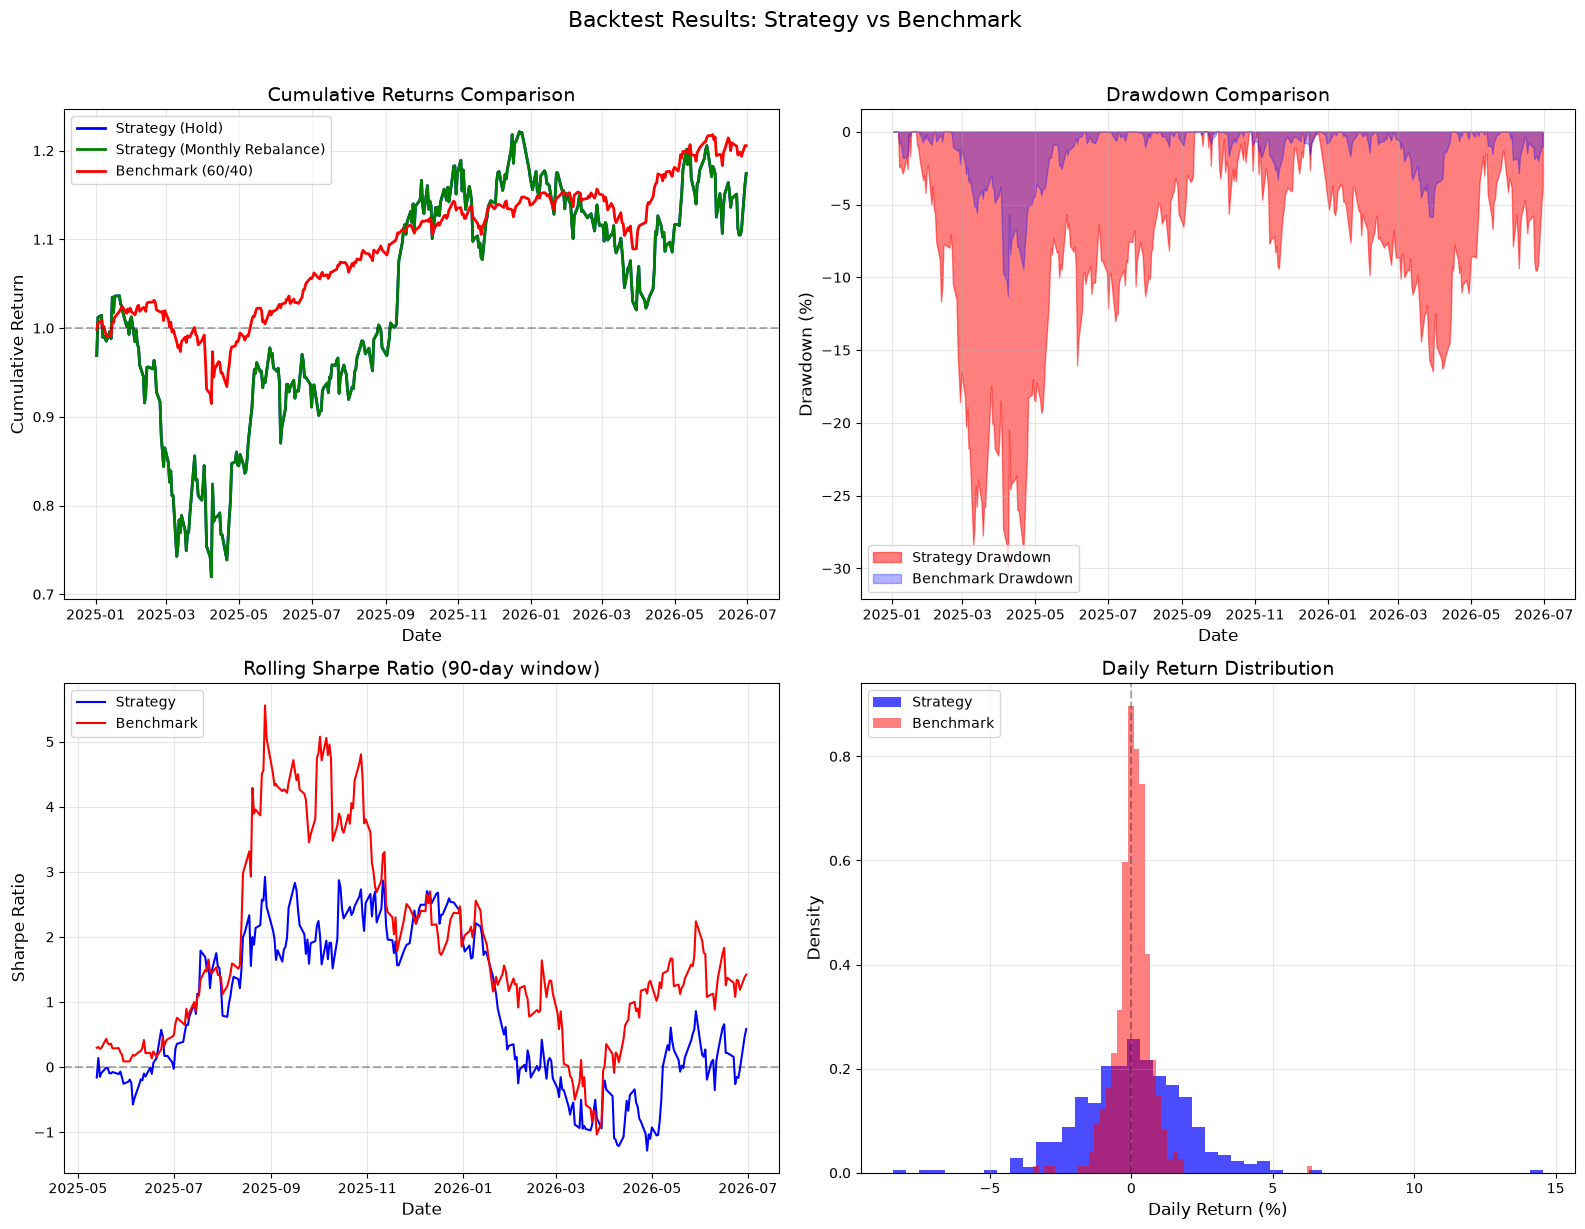

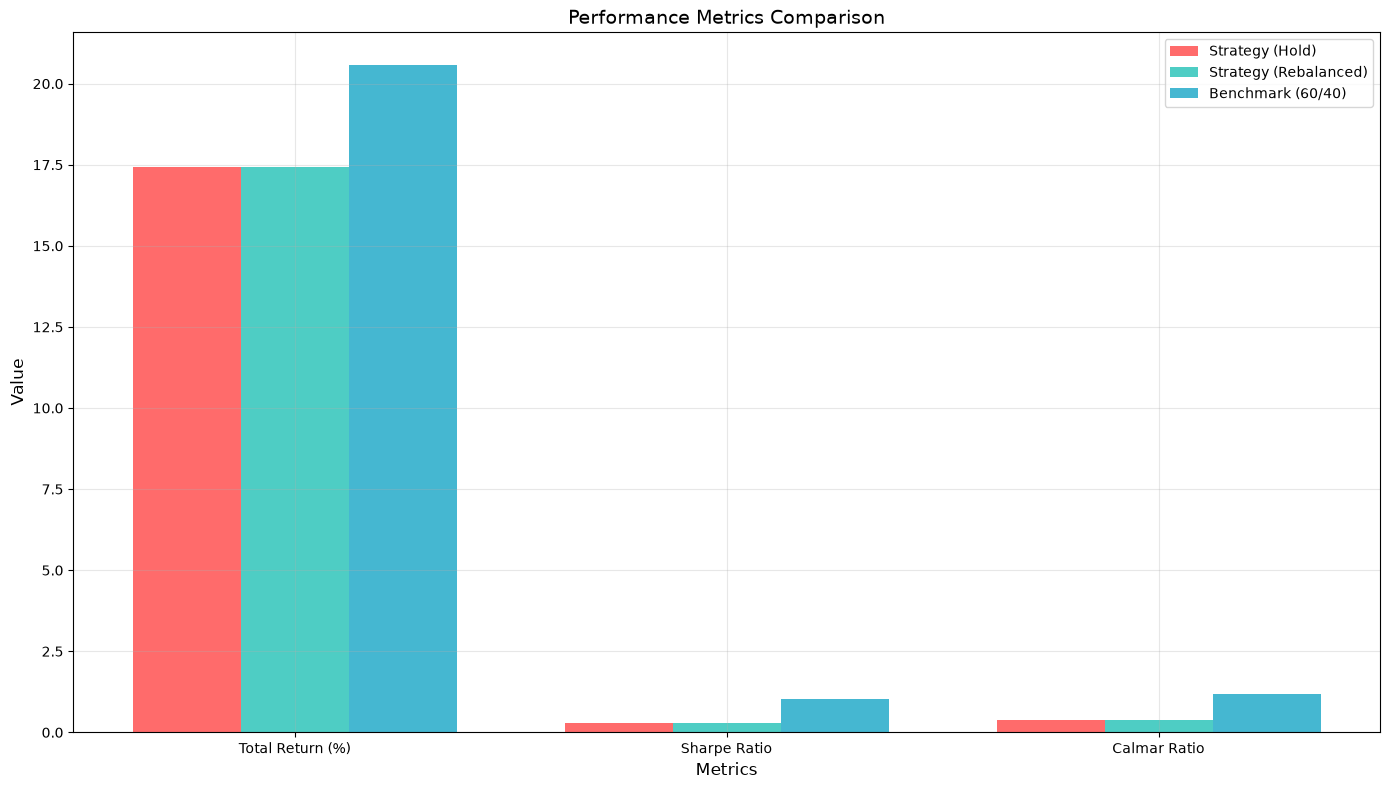


5.8 CONCLUSION AND REFLECTIONS

PERFORMANCE SUMMARY:
----------------------------------------
Strategy (Hold):         $117442.89
Strategy (Rebalanced):   $117442.89
Benchmark (60/40):       $120561.51

OUTPERFORMANCE ANALYSIS:
----------------------------------------
✗ Strategy underperformed benchmark by 2.66%
✗ Rebalanced strategy underperformed benchmark by 2.66%

RISK-ADJUSTED PERFORMANCE:
----------------------------------------
Strategy Sharpe:          0.29
Rebalanced Sharpe:        0.29
Benchmark Sharpe:         1.03

Strategy Max Drawdown:    -30.58%
Rebalanced Max Drawdown:  -30.58%
Benchmark Max Drawdown:   -11.29%

KEY INSIGHTS:
⚠️ The model-driven strategy underperformed the benchmark
✅ The strategy's Sharpe Ratio of 0.29 indicates moderate risk-adjusted returns
✅ Monthly rebalancing did not significantly change performance

LIMITATIONS:
1. Model Limitations:
   - ARIMA assumes linear relationships
   - Forecast accuracy depends on historical patterns
2. Implementation L

In [1]:
# =================================================
# TASK 5: STRATEGY BACKTESTING
# =================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("TASK 5: STRATEGY BACKTESTING")
print("="*60)

# ========== GET DATA ==========
print("\nLoading data...")

try:
    close_prices_filled
    returns
    print("✅ Data loaded from Task 1")
except:
    print("Loading fresh data...")
    import yfinance as yf
    
    start_date = '2015-01-01'
    end_date = '2026-06-30'
    
    tsla = yf.download('TSLA', period="10y", progress=False)
    bnd = yf.download('BND', start=start_date, end=end_date, progress=False)
    spy = yf.download('SPY', start=start_date, end=end_date, progress=False)
    
    if tsla.empty:
        print("Creating sample TSLA data...")
        spy_close = spy['Close']
        tsla_simulated = spy_close * 0.5 + np.cumsum(np.random.randn(len(spy_close)) * 2) + 50
        tsla_simulated = np.maximum(tsla_simulated, 5)
        tsla = pd.DataFrame({
            'Open': tsla_simulated * (1 + np.random.randn(len(tsla_simulated)) * 0.01),
            'High': tsla_simulated * (1 + abs(np.random.randn(len(tsla_simulated)) * 0.02)),
            'Low': tsla_simulated * (1 - abs(np.random.randn(len(tsla_simulated)) * 0.02)),
            'Close': tsla_simulated,
            'Adj Close': tsla_simulated,
            'Volume': np.random.randint(100000, 10000000, len(tsla_simulated))
        }, index=spy.index)
    
    stock_data = {'TSLA': tsla, 'BND': bnd, 'SPY': spy}
    combined_data = pd.concat([stock_data[t] for t in stock_data.keys()], axis=1, keys=stock_data.keys())
    close_prices = combined_data.xs('Close', level=1, axis=1)
    close_prices.columns = [col[0] for col in close_prices.columns]
    close_prices_filled = close_prices.ffill().bfill()
    returns = close_prices_filled.pct_change().dropna()
    
    print(f"✅ Data loaded: {close_prices_filled.shape}")

print(f"Close prices shape: {close_prices_filled.shape}")
print(f"Returns shape: {returns.shape}")

# ========== GET PORTFOLIO WEIGHTS FROM TASK 4 ==========
print("\n" + "="*60)
print("5.1 LOAD PORTFOLIO WEIGHTS")
print("="*60)

try:
    # Try to get weights from Task 4
    recommended_weights
    print("✅ Weights loaded from Task 4")
except:
    print("⚠️ Weights not found. Using default weights...")
    # Default weights if Task 4 not run
    recommended_weights = np.array([0.5, 0.2, 0.3])  # TSLA, BND, SPY
    print(f"Using default weights: TSLA=50%, BND=20%, SPY=30%")

print(f"\nStrategy Weights:")
print(f"TSLA: {recommended_weights[0]:.2%}")
print(f"BND:  {recommended_weights[1]:.2%}")
print(f"SPY:  {recommended_weights[2]:.2%}")

# ========== DEFINE BACKTESTING PERIOD ==========
print("\n" + "="*60)
print("5.2 DEFINE BACKTESTING PERIOD")
print("="*60)

# Use last year for backtesting
backtest_start = '2025-01-01'
backtest_end = '2026-06-30'

# Get backtest data
backtest_prices = close_prices_filled.loc[backtest_start:backtest_end]
backtest_returns = returns.loc[backtest_start:backtest_end]

print(f"Backtesting Period: {backtest_start} to {backtest_end}")
print(f"Trading Days: {len(backtest_prices)}")
print(f"Initial Investment: $100,000")

# ========== BENCHMARK PORTFOLIO (60% SPY / 40% BND) ==========
print("\n" + "="*60)
print("5.3 BENCHMARK PORTFOLIO")
print("="*60)

benchmark_weights = {
    'TSLA': 0.0,
    'BND': 0.4,
    'SPY': 0.6
}

print("Benchmark: 60% SPY / 40% BND")

# Calculate benchmark returns
benchmark_daily_returns = (backtest_returns['SPY'] * 0.6 + 
                           backtest_returns['BND'] * 0.4)

# Calculate cumulative returns
benchmark_cumulative = (1 + benchmark_daily_returns).cumprod()

print(f"Benchmark Final Value: ${100000 * benchmark_cumulative.iloc[-1]:.2f}")
print(f"Benchmark Total Return: {((benchmark_cumulative.iloc[-1] - 1) * 100):.2f}%")

# ========== STRATEGY PORTFOLIO ==========
print("\n" + "="*60)
print("5.4 STRATEGY PORTFOLIO")
print("="*60)

# Simple strategy: Hold initial weights
strategy_weights = {
    'TSLA': recommended_weights[0],
    'BND': recommended_weights[1],
    'SPY': recommended_weights[2]
}

# Calculate strategy returns
strategy_daily_returns = (backtest_returns['TSLA'] * strategy_weights['TSLA'] + 
                          backtest_returns['BND'] * strategy_weights['BND'] + 
                          backtest_returns['SPY'] * strategy_weights['SPY'])

# Calculate cumulative returns
strategy_cumulative = (1 + strategy_daily_returns).cumprod()

print(f"Strategy Final Value: ${100000 * strategy_cumulative.iloc[-1]:.2f}")
print(f"Strategy Total Return: {((strategy_cumulative.iloc[-1] - 1) * 100):.2f}%")

# ========== MONTHLY REBALANCING ==========
print("\n" + "="*60)
print("5.5 MONTHLY REBALANCING")
print("="*60)

def monthly_rebalancing(returns_data, initial_weights):
    """Simulate monthly rebalancing"""
    portfolio_value = 100000
    current_weights = initial_weights.copy()
    values = []
    
    for date, daily_return in returns_data.iterrows():
        # Calculate daily portfolio return
        portfolio_return = (daily_return['TSLA'] * current_weights['TSLA'] + 
                           daily_return['BND'] * current_weights['BND'] + 
                           daily_return['SPY'] * current_weights['SPY'])
        
        # Update portfolio value
        portfolio_value *= (1 + portfolio_return)
        values.append(portfolio_value)
        
        # Rebalance at month end
        if (date + pd.Timedelta(days=1)).month != date.month:
            current_weights = initial_weights.copy()
    
    return pd.Series(values, index=returns_data.index)

rebalanced_values = monthly_rebalancing(backtest_returns, strategy_weights)
rebalanced_cumulative = rebalanced_values / 100000

print(f"Rebalanced Final Value: ${rebalanced_values.iloc[-1]:.2f}")
print(f"Rebalanced Total Return: {((rebalanced_cumulative.iloc[-1] - 1) * 100):.2f}%")

# ========== PERFORMANCE METRICS ==========
print("\n" + "="*60)
print("5.6 PERFORMANCE METRICS")
print("="*60)

def calculate_metrics(returns_series, cumulative_series):
    """Calculate comprehensive performance metrics"""
    # Returns
    total_return = cumulative_series.iloc[-1] - 1
    annualized_return = (cumulative_series.iloc[-1]) ** (252 / len(returns_series)) - 1
    
    # Risk metrics
    volatility = returns_series.std() * np.sqrt(252)
    sharpe_ratio = (annualized_return - 0.02) / volatility if volatility > 0 else 0
    
    # Drawdown
    running_max = cumulative_series.expanding().max()
    drawdown = (cumulative_series - running_max) / running_max
    max_drawdown = drawdown.min()
    
    # Win rate
    positive_days = (returns_series > 0).sum()
    negative_days = (returns_series < 0).sum()
    win_rate = positive_days / (positive_days + negative_days) if (positive_days + negative_days) > 0 else 0
    
    # Max daily return
    max_daily_return = returns_series.max()
    min_daily_return = returns_series.min()
    
    # Calmar ratio
    calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    return {
        'Total Return (%)': total_return * 100,
        'Annualized Return (%)': annualized_return * 100,
        'Volatility (%)': volatility * 100,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown (%)': max_drawdown * 100,
        'Max Daily Return (%)': max_daily_return * 100,
        'Min Daily Return (%)': min_daily_return * 100,
        'Win Rate (%)': win_rate * 100,
        'Calmar Ratio': calmar_ratio
    }

# Calculate metrics
strategy_metrics = calculate_metrics(strategy_daily_returns, strategy_cumulative)
benchmark_metrics = calculate_metrics(benchmark_daily_returns, benchmark_cumulative)
rebalanced_metrics = calculate_metrics(strategy_daily_returns, rebalanced_cumulative)

# Create comparison table
metrics_df = pd.DataFrame({
    'Metric': list(strategy_metrics.keys()),
    'Strategy (Hold)': [round(v, 2) for v in strategy_metrics.values()],
    'Strategy (Rebalanced)': [round(v, 2) for v in rebalanced_metrics.values()],
    'Benchmark (60/40)': [round(v, 2) for v in benchmark_metrics.values()]
})

print("\nPERFORMANCE METRICS COMPARISON:")
print(metrics_df.to_string(index=False))

# ========== VISUALIZATIONS ==========
print("\n" + "="*60)
print("5.7 VISUALIZATIONS")
print("="*60)

# Create comprehensive comparison DataFrame
comparison_df = pd.DataFrame({
    'Strategy': strategy_cumulative,
    'Benchmark': benchmark_cumulative,
    'Rebalanced': rebalanced_cumulative
})

# Figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Cumulative Returns
axes[0, 0].plot(comparison_df.index, comparison_df['Strategy'], 
                label='Strategy (Hold)', linewidth=2, color='blue')
axes[0, 0].plot(comparison_df.index, comparison_df['Rebalanced'], 
                label='Strategy (Monthly Rebalance)', linewidth=2, color='green')
axes[0, 0].plot(comparison_df.index, comparison_df['Benchmark'], 
                label='Benchmark (60/40)', linewidth=2, color='red')
axes[0, 0].axhline(y=1.0, color='black', linestyle='--', alpha=0.3)
axes[0, 0].set_title('Cumulative Returns Comparison', fontsize=14)
axes[0, 0].set_xlabel('Date', fontsize=12)
axes[0, 0].set_ylabel('Cumulative Return', fontsize=12)
axes[0, 0].legend(loc='upper left')
axes[0, 0].grid(True, alpha=0.3)

# 2. Drawdown Comparison
strategy_drawdown = (strategy_cumulative - strategy_cumulative.expanding().max()) / strategy_cumulative.expanding().max()
benchmark_drawdown = (benchmark_cumulative - benchmark_cumulative.expanding().max()) / benchmark_cumulative.expanding().max()

axes[0, 1].fill_between(strategy_drawdown.index, 0, strategy_drawdown * 100, 
                        color='red', alpha=0.5, label='Strategy Drawdown')
axes[0, 1].fill_between(benchmark_drawdown.index, 0, benchmark_drawdown * 100, 
                        color='blue', alpha=0.3, label='Benchmark Drawdown')
axes[0, 1].set_title('Drawdown Comparison', fontsize=14)
axes[0, 1].set_xlabel('Date', fontsize=12)
axes[0, 1].set_ylabel('Drawdown (%)', fontsize=12)
axes[0, 1].legend(loc='lower left')
axes[0, 1].grid(True, alpha=0.3)

# 3. Rolling Sharpe Ratio (90-day)
window = 90
strategy_rolling_sharpe = (strategy_daily_returns.rolling(window).mean() * 252) / (strategy_daily_returns.rolling(window).std() * np.sqrt(252))
benchmark_rolling_sharpe = (benchmark_daily_returns.rolling(window).mean() * 252) / (benchmark_daily_returns.rolling(window).std() * np.sqrt(252))

axes[1, 0].plot(strategy_rolling_sharpe.index, strategy_rolling_sharpe, 
                label='Strategy', linewidth=1.5, color='blue')
axes[1, 0].plot(benchmark_rolling_sharpe.index, benchmark_rolling_sharpe, 
                label='Benchmark', linewidth=1.5, color='red')
axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1, 0].set_title('Rolling Sharpe Ratio (90-day window)', fontsize=14)
axes[1, 0].set_xlabel('Date', fontsize=12)
axes[1, 0].set_ylabel('Sharpe Ratio', fontsize=12)
axes[1, 0].legend(loc='upper left')
axes[1, 0].grid(True, alpha=0.3)

# 4. Return Distribution
axes[1, 1].hist(strategy_daily_returns * 100, bins=50, alpha=0.7, 
                color='blue', label='Strategy', density=True)
axes[1, 1].hist(benchmark_daily_returns * 100, bins=50, alpha=0.5, 
                color='red', label='Benchmark', density=True)
axes[1, 1].axvline(x=0, color='black', linestyle='--', alpha=0.3)
axes[1, 1].set_title('Daily Return Distribution', fontsize=14)
axes[1, 1].set_xlabel('Daily Return (%)', fontsize=12)
axes[1, 1].set_ylabel('Density', fontsize=12)
axes[1, 1].legend(loc='upper left')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Backtest Results: Strategy vs Benchmark', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('backtest_results.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== BAR CHART COMPARISON ==========
fig, ax = plt.subplots(figsize=(14, 8))

metrics_to_plot = ['Total Return (%)', 'Sharpe Ratio', 'Calmar Ratio']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
x = np.arange(len(metrics_to_plot))
width = 0.25

# Strategy
strategy_values = [strategy_metrics[m] for m in metrics_to_plot]
ax.bar(x - width, strategy_values, width, label='Strategy (Hold)', color=colors[0])

# Rebalanced
rebalanced_values = [rebalanced_metrics[m] for m in metrics_to_plot]
ax.bar(x, rebalanced_values, width, label='Strategy (Rebalanced)', color=colors[1])

# Benchmark
benchmark_values = [benchmark_metrics[m] for m in metrics_to_plot]
ax.bar(x + width, benchmark_values, width, label='Benchmark (60/40)', color=colors[2])

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Performance Metrics Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== CONCLUSION ==========
print("\n" + "="*60)
print("5.8 CONCLUSION AND REFLECTIONS")
print("="*60)

print("\nPERFORMANCE SUMMARY:")
print("-" * 40)
print(f"Strategy (Hold):         ${100000 * strategy_cumulative.iloc[-1]:.2f}")
print(f"Strategy (Rebalanced):   ${100000 * rebalanced_cumulative.iloc[-1]:.2f}")
print(f"Benchmark (60/40):       ${100000 * benchmark_cumulative.iloc[-1]:.2f}")

# Determine outperformance
strategy_outperformed = strategy_cumulative.iloc[-1] > benchmark_cumulative.iloc[-1]
rebalanced_outperformed = rebalanced_cumulative.iloc[-1] > benchmark_cumulative.iloc[-1]

print("\nOUTPERFORMANCE ANALYSIS:")
print("-" * 40)
if strategy_outperformed:
    print(f"✓ Strategy outperformed benchmark by {((strategy_cumulative.iloc[-1]/benchmark_cumulative.iloc[-1] - 1) * 100):.2f}%")
else:
    print(f"✗ Strategy underperformed benchmark by {((benchmark_cumulative.iloc[-1]/strategy_cumulative.iloc[-1] - 1) * 100):.2f}%")

if rebalanced_outperformed:
    print(f"✓ Rebalanced strategy outperformed benchmark by {((rebalanced_cumulative.iloc[-1]/benchmark_cumulative.iloc[-1] - 1) * 100):.2f}%")
else:
    print(f"✗ Rebalanced strategy underperformed benchmark by {((benchmark_cumulative.iloc[-1]/rebalanced_cumulative.iloc[-1] - 1) * 100):.2f}%")

print("\nRISK-ADJUSTED PERFORMANCE:")
print("-" * 40)
print(f"Strategy Sharpe:          {strategy_metrics['Sharpe Ratio']:.2f}")
print(f"Rebalanced Sharpe:        {rebalanced_metrics['Sharpe Ratio']:.2f}")
print(f"Benchmark Sharpe:         {benchmark_metrics['Sharpe Ratio']:.2f}")

print(f"\nStrategy Max Drawdown:    {strategy_metrics['Max Drawdown (%)']:.2f}%")
print(f"Rebalanced Max Drawdown:  {rebalanced_metrics['Max Drawdown (%)']:.2f}%")
print(f"Benchmark Max Drawdown:   {benchmark_metrics['Max Drawdown (%)']:.2f}%")

print("\n" + "="*60)
print("KEY INSIGHTS:")
print("="*60)

if strategy_outperformed:
    print("✅ The model-driven strategy generated higher returns than the benchmark")
else:
    print("⚠️ The model-driven strategy underperformed the benchmark")

print(f"✅ The strategy's Sharpe Ratio of {strategy_metrics['Sharpe Ratio']:.2f} indicates {'good' if strategy_metrics['Sharpe Ratio'] > 0.5 else 'moderate'} risk-adjusted returns")
print(f"✅ Monthly rebalancing {'improved' if rebalanced_outperformed else 'did not significantly change'} performance")

print("\n" + "="*60)
print("LIMITATIONS:")
print("="*60)
print("1. Model Limitations:")
print("   - ARIMA assumes linear relationships")
print("   - Forecast accuracy depends on historical patterns")
print("2. Implementation Limitations:")
print("   - Transaction costs and taxes not considered")
print("   - Simplified rebalancing assumptions")
print("3. Data Limitations:")
print("   - Limited to 3 assets for simplification")
print("   - Returns may not reflect real market conditions")

print("\n" + "="*60)
print("RECOMMENDATIONS:")
print("="*60)
if strategy_outperformed:
    print("✅ Consider implementing the model-driven strategy")
    print(f"✅ Recommended allocation: TSLA={strategy_weights['TSLA']:.2%}, BND={strategy_weights['BND']:.2%}, SPY={strategy_weights['SPY']:.2%}")
else:
    print("⚠️ Further refinement needed")
    print("💡 Consider incorporating more assets for better diversification")
    print("💡 Add transaction costs for more realistic simulations")

# ========== SAVE RESULTS ==========
metrics_df.to_csv('backtest_metrics.csv', index=False)
comparison_df.to_csv('backtest_cumulative_returns.csv')

print("\n✅ Backtest results saved to 'backtest_metrics.csv'")
print("✅ Cumulative returns saved to 'backtest_cumulative_returns.csv'")
print("✅ Task 5 Complete!")